# Reproducing *Geometric Dynamics Across Recurrent Vision Models*

Luo, Alvarez & Konkle, CCN 2026.

This notebook regenerates **every table and figure in the paper** from the
saved activations. It needs no GPU, no TensorFlow, and no model code — just
the activation tensors (see the README for the download link) and the
`repgeo` package in this repo.

| Paper item | Section below |
|---|---|
| Table 1 — models & accuracy | §1 |
| Table 2 + Figure 1 — local/global dynamics | §2 |
| Figure 2 — decision-stage prototype distances | §3 |
| Figure 3 — cross-model RSA & MDS | §4 |
| Figure 4 (supplement) — ConvRNN t=12→t=17 | §5 |

Each cell prints the numbers reported in the paper so you can check the
reproduction as you go. Run top to bottom.

In [1]:
# --- Setup ---------------------------------------------------------------
# Recommended one-time install (from the repo root):   pip install -e .
# After that, `import repgeo` works no matter where Jupyter was launched.
# The fallback below also lets this notebook run without installing,
# as long as it stays inside the repo's notebooks/ folder.
try:
    import repgeo
except ImportError:
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path().resolve().parent))
    import repgeo

# --- Point these at your downloaded activations ----------------------------
# ACTIVATIONS = "../activations"      # directory with one subfolder per model
# SUFFIX      = "imagenetval_100x50"  # dataset tag embedded in every filename

# for self-testing
ACTIVATIONS = "/teamspace/studios/this_studio/reprGeo_output"
SUFFIX      = "imagenetval_100*50"   # local files use the old * naming

import torch
from repgeo import load_features, sanity_check

features, labels = load_features(ACTIVATIONS, suffix=SUFFIX)
sanity_check(features, labels)   # checks every tensor has 5000 rows / 100 classes

[LRM3            ][logits ][baseline] -> (5000, 1000)
[LRM3            ][logits ][after   ] -> (5000, 1000)
[LRM3            ][penult ][baseline] -> (5000, 4096)
[LRM3            ][penult ][after   ] -> (5000, 4096)
[LRA3            ][logits ][baseline] -> (5000, 1000)
[LRA3            ][logits ][after   ] -> (5000, 1000)
[LRA3            ][penult ][baseline] -> (5000, 4096)
[LRA3            ][penult ][after   ] -> (5000, 4096)
[BL              ][logits ][baseline] -> (5000, 1000)
[BL              ][logits ][after   ] -> (5000, 1000)
[BL              ][penult ][baseline] -> (5000, 2048)
[BL              ][penult ][after   ] -> (5000, 2048)
[CORnet-RT       ][logits ][baseline] -> (5000, 1000)
[CORnet-RT       ][logits ][after   ] -> (5000, 1000)
[CORnet-RT       ][penult ][baseline] -> (5000, 512)
[CORnet-RT       ][penult ][after   ] -> (5000, 512)
[ConvRNN         ][logits ][baseline] -> (5000, 1000)
[ConvRNN         ][logits ][after   ] -> (5000, 1000)
[ConvRNN         ][penult ][ba

[]

## §1 — Table 1: models and accuracy

Two accuracy measures per model and processing stage (baseline → after
recurrence):

* **Top-1 (logits)** — standard ImageNet accuracy from the model's own
  classifier (`source="logits"`).
* **NC Penult. Top-1** — nearest-centroid accuracy on the penultimate layer:
  each image is assigned to the nearest category prototype in cosine
  distance (`source="penult"`). A classifier-independent separability
  measure comparable across all models.

Expected (paper Table 1):

| Model | logits base→after | NC penult base→after |
|---|---|---|
| LRM3 | 57.4 → 59.0 | 80.6 → 83.2 |
| LRA3 | 57.7 → 58.5 | 80.9 → 82.7 |
| BL | 51.1 → 57.0 | 76.0 → 83.4 |
| CORnet-RT | – → 56.2 | 52.5 → 75.9 |
| ConvRNN | 68.0 → 70.9 | 90.0 → 90.1 |

In [2]:
from repgeo import accuracy_table

print("Standard ImageNet Top-1/5 (logits argmax):")
display(accuracy_table(features, labels, source="logits"))

print("Nearest-centroid Top-1/5 on penultimate features:")
display(accuracy_table(features, labels, source="penult"))

Standard ImageNet Top-1/5 (logits argmax):


,Model,State,Top-1 (%),Top-5 (%),N
0,LRM3,baseline,57.36,79.84,5000
1,LRM3,after,58.98,81.56,5000
2,LRA3,baseline,57.74,79.86,5000
3,LRA3,after,58.48,81.34,5000
4,BL,baseline,51.06,75.76,5000
5,BL,after,57.02,80.96,5000
6,CORnet-RT,baseline,0.30,1.76,5000
7,CORnet-RT,after,56.20,79.68,5000
8,ConvRNN,baseline,67.96,88.92,5000
9,ConvRNN,after,70.90,90.38,5000


Nearest-centroid Top-1/5 on penultimate features:


,Model,State,Top-1 (%),Top-5 (%),N
0,LRM3,baseline,80.60,95.62,5000
1,LRM3,after,83.20,96.52,5000
2,LRA3,baseline,80.86,95.90,5000
3,LRA3,after,82.68,96.60,5000
4,BL,baseline,75.98,92.86,5000
5,BL,after,83.44,95.86,5000
6,CORnet-RT,baseline,52.52,78.54,5000
7,CORnet-RT,after,75.90,92.94,5000
8,ConvRNN,baseline,90.04,98.20,5000
9,ConvRNN,after,90.14,98.02,5000


**Why CORnet-RT is analyzed at the penultimate layer.** The paper notes
that CORnet-RT's *logits* at the baseline step are not a meaningful decision
readout — nearest-centroid separability there is only **43.6%** — whereas
ConvRNN's baseline logits are already well separated (**82.0%**). We confirm
both numbers below; this is why CORnet-RT uses the penultimate layer in the
main analyses while the other recurrent models use logits.

In [3]:
from repgeo import nearest_centroid_accuracy

labels_t = torch.as_tensor(labels)
classes = torch.unique(labels_t, sorted=True).tolist()
for m in ["CORnet-RT", "ConvRNN"]:
    top1, _ = nearest_centroid_accuracy(features[m]["logits"]["baseline"], labels_t, classes)
    print(f"{m:10s} baseline-logits nearest-centroid Top-1 = {top1:.1f}%")

CORnet-RT  baseline-logits nearest-centroid Top-1 = 43.6%
ConvRNN    baseline-logits nearest-centroid Top-1 = 82.0%


## §2 — Table 2 & Figure 1: local and global dynamics

The headline result. For each recurrent model we contrast the baseline and
after-recurrence stages (CORnet-RT on penultimate, the rest on logits):

* **Local** — change in exemplar-to-prototype cosine distance
  (negative = compaction, exemplars tighten toward their prototype).
* **Global** — prototype shift, change in between-prototype separation
  (centered), and how well the prototype RDM is preserved.

### Table 2

Expected: LRM3 −0.031 / −6.52 / 0.017 / +0.21 / 0.955; LRA3 −0.021 / −4.46 /
0.010 / +0.18 / 0.973; BL +0.014 / +6.58 / 0.028 / +3.90 / 0.977; CORnet-RT
−0.100 / −38.80 / 0.441 / +3.38 / 0.804; ConvRNN +0.023 / +11.50 / 0.018 /
+2.13 / 0.978.

In [4]:
from repgeo import geometry_summary_table

geometry_summary_table(features, labels).round(3)

,Model,Rep,Δ Cluster Size,Δ Cluster Size (%),Avg Proto Shift,Δ Between-Proto (%),Proto RDM ρ
0,LRM3,logits,-0.031,-6.516,0.017,0.207,0.955
1,LRA3,logits,-0.021,-4.456,0.010,0.181,0.973
2,BL,logits,0.014,6.584,0.028,3.905,0.977
3,CORnet-RT,penult,-0.100,-38.819,0.441,3.380,0.804
4,ConvRNN,logits,0.023,11.528,0.018,2.125,0.978


### Figure 1 — local/global composite

Top row: local cluster-size-change KDE per model (red dashed = mean, black =
zero). Bottom row: prototype shifts in the baseline-PCA space (gray = baseline,
red = after). CORnet-RT uses the penultimate layer (`rep_overrides`).

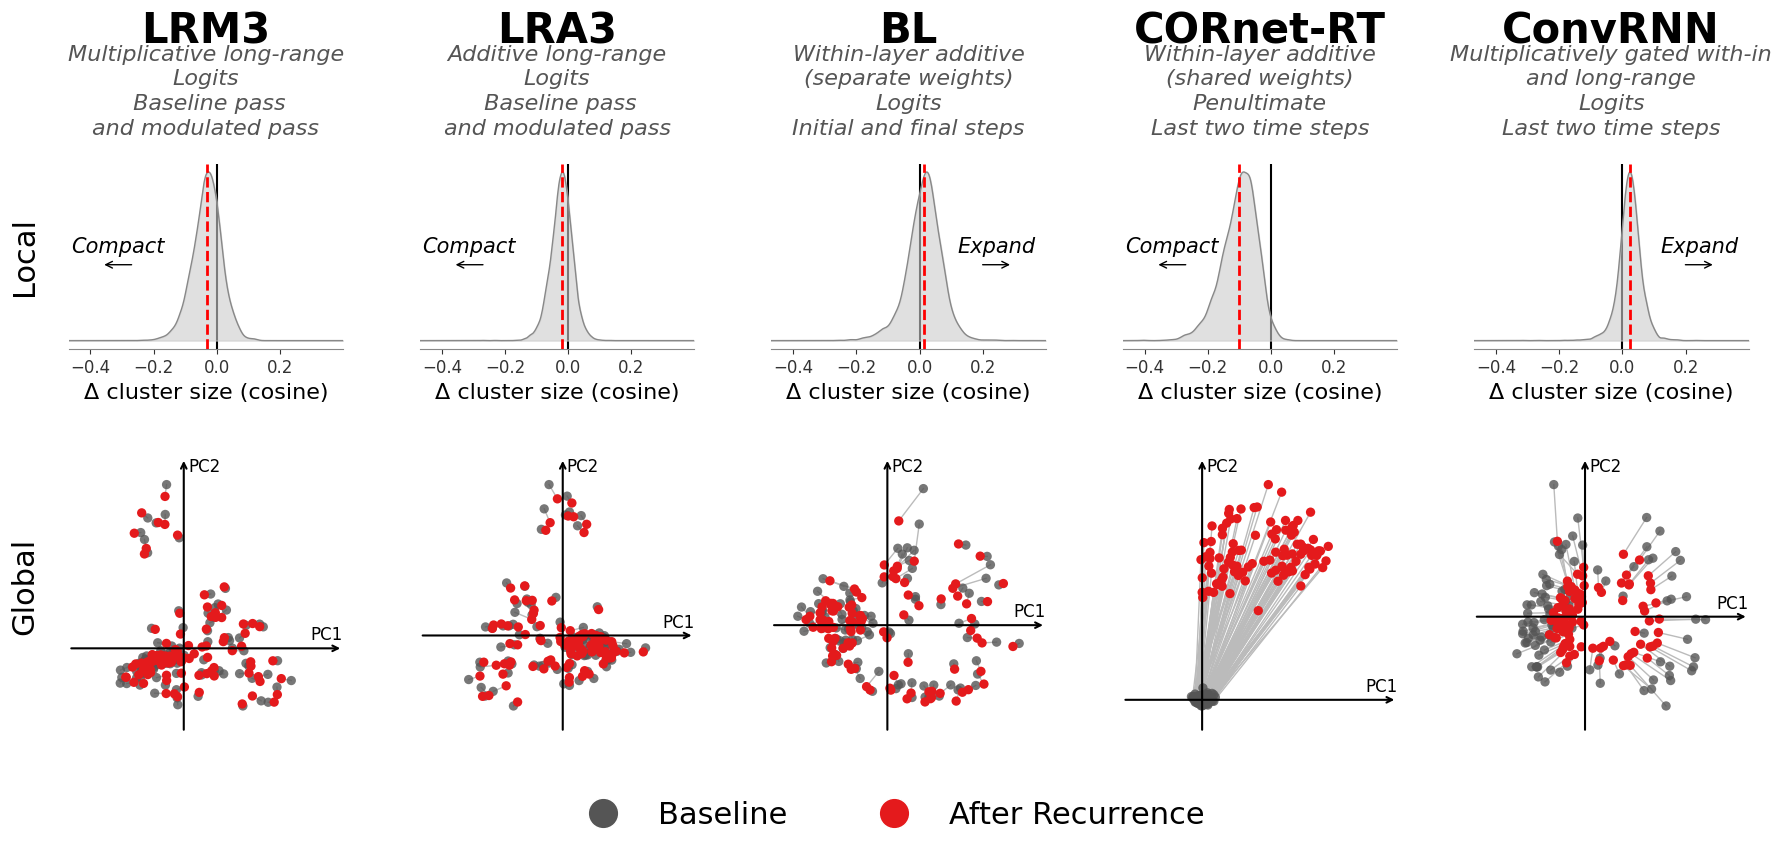

In [5]:
from repgeo import plotting as P

P.plot_local_global_composite(
    features, labels, rep="logits",
    rep_overrides={"CORnet-RT": "penult"})

### Significance tests

* **Local** — linear mixed-effects model on the per-exemplar distance change,
  random intercepts by category. The paper reports all five models
  significant at *p* < .001.
* **Global** — permutation test (10,000 iterations) swapping the
  baseline/after label per exemplar; also *p* < .001 for all models.

The permutation test is the slow step (~a minute at 10k). Drop `n_perm` to
preview, or raise it back to 10000 to match the paper.

In [6]:
from repgeo import run_local_lme_tests, run_global_permutation_tests

print("Local (mixed-effects, distance_diff ~ 1 + (1|category)):")
display(run_local_lme_tests(features, labels))

print("Global (between-prototype separation, permutation test):")
display(run_global_permutation_tests(features, labels, n_perm=10000))

Local (mixed-effects, distance_diff ~ 1 + (1|category)):


,Model,Rep,beta,SE,95% CI lo,95% CI hi,p-value,Direction
0,LRM3,logits,-0.031038,0.002119,-0.035190,-0.026886,1.339442e-48,compaction
1,LRA3,logits,-0.021206,0.001528,-0.024202,-0.018211,8.818676e-44,compaction
2,BL,logits,0.014048,0.001775,0.010569,0.017527,2.497447e-15,expansion
3,CORnet-RT,penult,-0.100120,0.001990,-0.104020,-0.096221,0.000000e+00,compaction
4,ConvRNN,logits,0.023382,0.001585,0.020276,0.026488,2.845426e-49,expansion


Global (between-prototype separation, permutation test):


,Model,Rep,obs_pct,p_two_tailed,p_greater,p_less
0,LRM3,logits,0.207025,0.0,0.0,1.0
1,LRA3,logits,0.181170,0.0,0.0,1.0
2,BL,logits,3.904939,0.0,0.0,1.0
3,CORnet-RT,penult,3.380208,0.0,0.0,1.0
4,ConvRNN,logits,2.125149,0.0,0.0,1.0


## §3 — Figure 2: learned decision-stage structure

Distribution of all 4,950 pairwise cosine distances between the 100 category
prototypes at the **logits** layer. A distribution concentrated near 1.0 means
prototypes are near-orthogonal (maximally separated). LRM/LRA and the standard
ResNets show this; AlexNet, B, VGG-16, and the other recurrent models do not.

Solid line = baseline, dotted = after recurrence. CLIP is omitted (no logits).

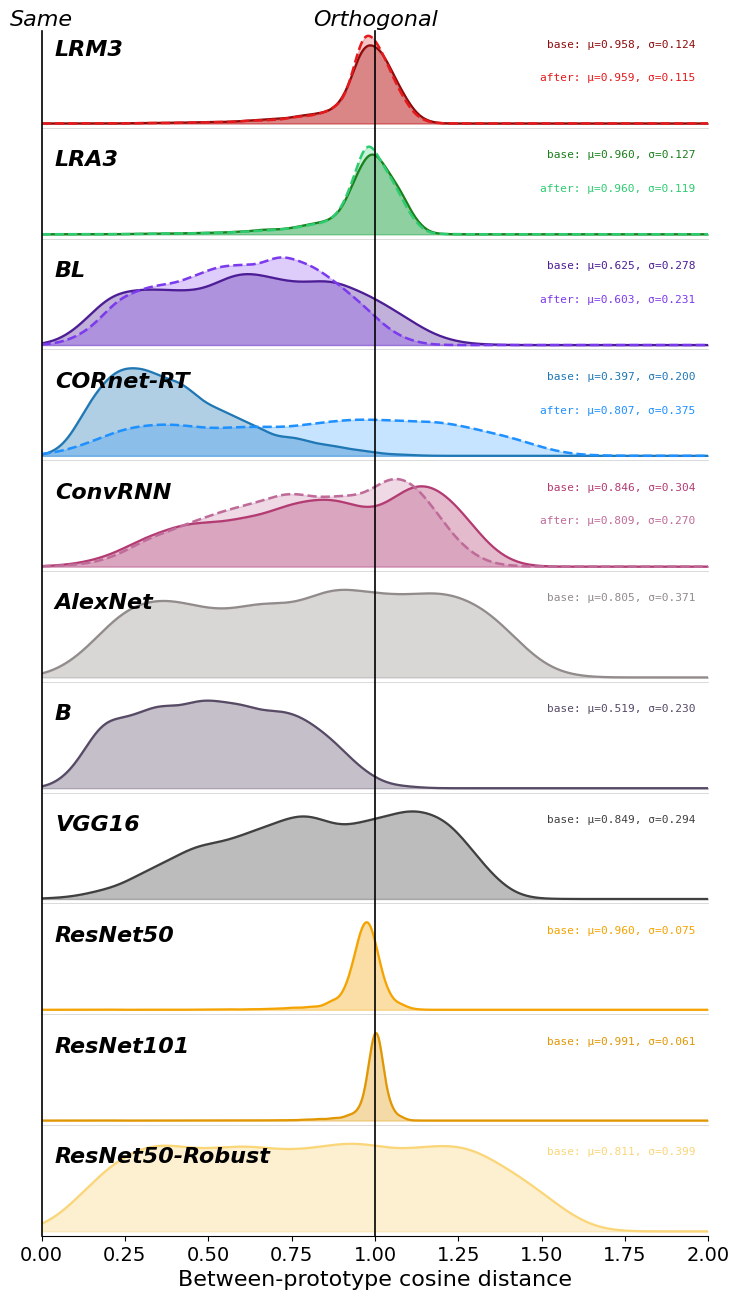

In [7]:
from repgeo import compute_cluster_sizes_and_rdms, between_prototype_summary

cluster_log, between_log = compute_cluster_sizes_and_rdms(features, labels, rep="logits")
P.plot_separation_ridge(between_log)

The in-text means ± SD (e.g. LRM 0.958±0.124 → 0.959±0.115; AlexNet
0.805±0.371; CORnet-RT 0.397±0.200 → 0.807±0.375; ResNet-101 0.991±0.061)
come straight from these distributions:

In [8]:
between_prototype_summary(between_log)

,Model/State,Mean,SD,n_pairs
0,LRM3 baseline,0.958,0.124,4950
1,LRM3 after,0.959,0.115,4950
2,LRA3 baseline,0.960,0.127,4950
3,LRA3 after,0.960,0.119,4950
4,BL baseline,0.625,0.278,4950
5,BL after,0.603,0.231,4950
6,CORnet-RT baseline,0.397,0.200,4950
7,CORnet-RT after,0.807,0.375,4950
8,ConvRNN baseline,0.846,0.304,4950
9,ConvRNN after,0.809,0.270,4950


## §4 — Figure 3: cross-model representational similarity

For each model/stage we build a 100×100 prototype distance matrix and
correlate the upper triangles across all model pairs (Spearman ρ). The 2×2
composite shows the cross-model RSA heatmaps (top) and MDS embeddings (bottom)
at the penultimate (left) and logits (right) layers. Models converge at the
feature stage but split into families at the decision stage.

/system/conda/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/system/conda/miniconda3/envs/cloudspace/lib/python3.10/site-packages/sklearn/manifold/_mds.py:298: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


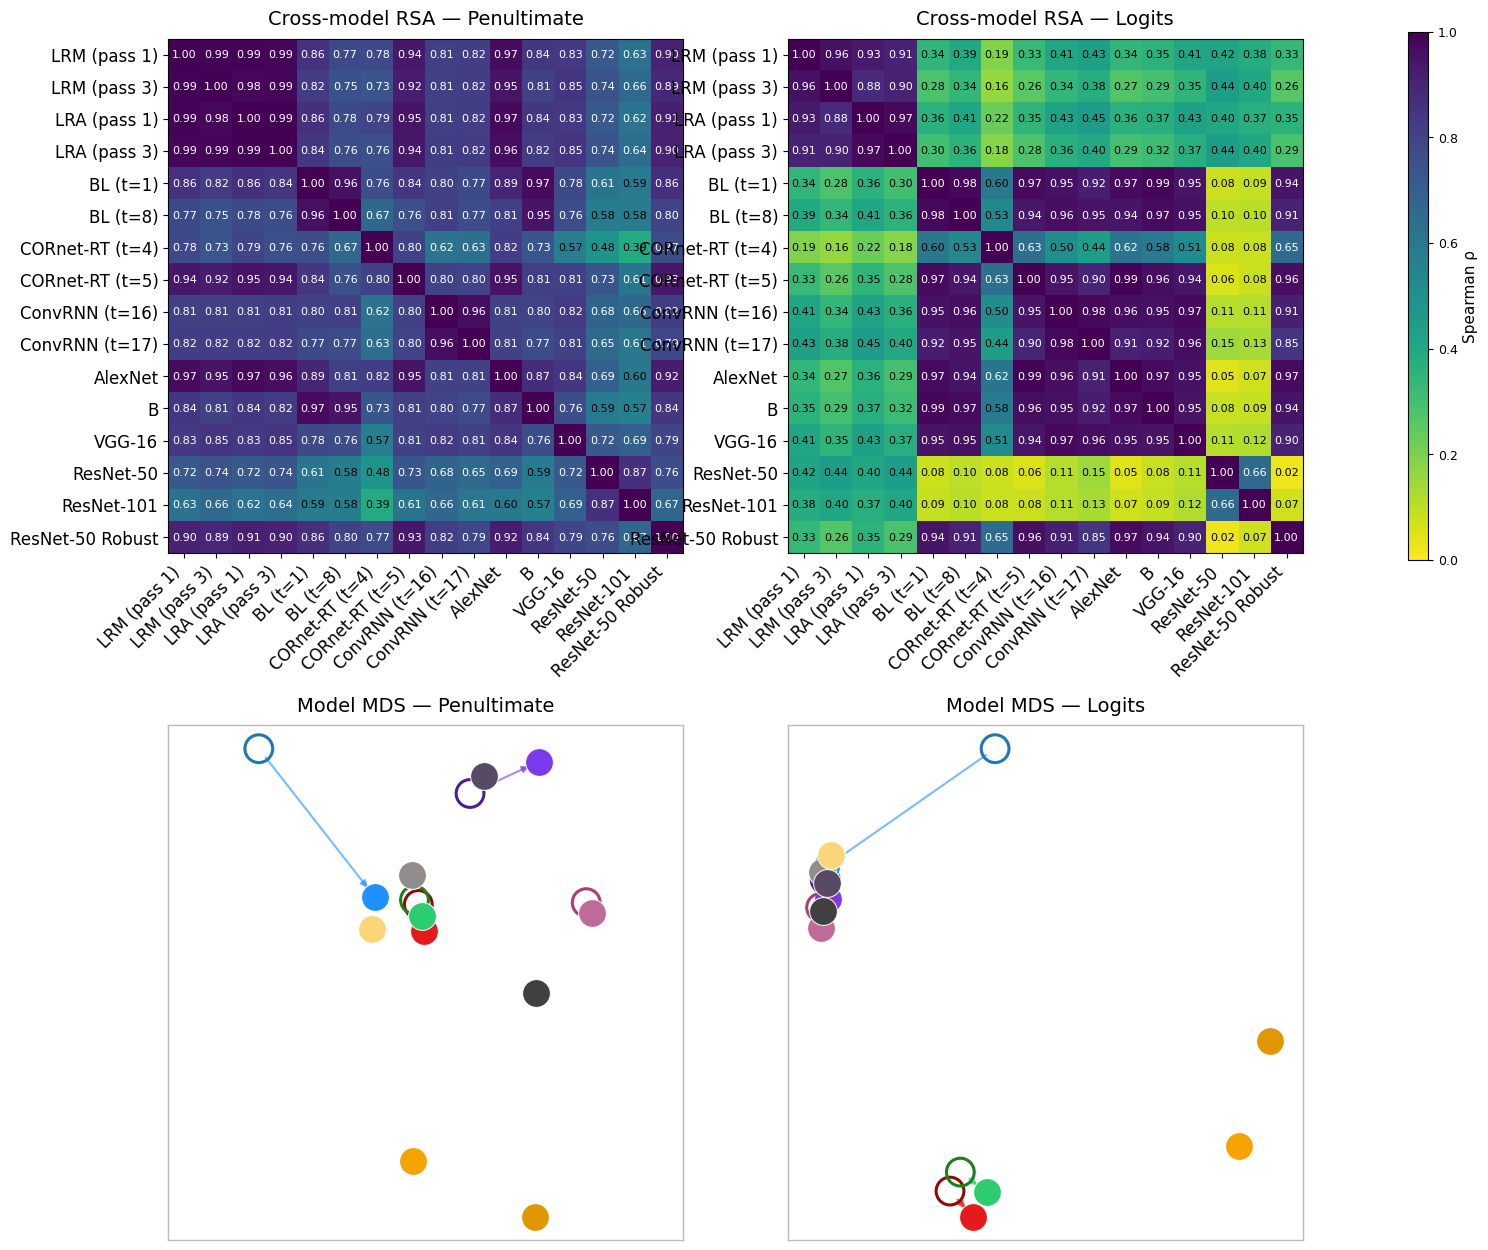

logits-MDS stress: 0.107   penult-MDS stress: 0.086


In [9]:
from repgeo import build_prototype_rdms

_, between_pen = compute_cluster_sizes_and_rdms(features, labels, rep="penult")
rdms_log = build_prototype_rdms(features, labels, rep="logits")
rdms_pen = build_prototype_rdms(features, labels, rep="penult")

results = P.plot_rsa_mds_composite(between_log, between_pen, rdms_log, rdms_pen)
print("logits-MDS stress:", round(results['mds_log'][3], 3),
      "  penult-MDS stress:", round(results['mds_pen'][3], 3))

In [ ]:
# Interactive 3-D version of the MDS (drag to rotate); needs plotly
# P.plot_model_mds_3d(rdms_log, "Model MDS 3-D — LOGITS");

## §5 — Figure 4 (supplement): ConvRNN input-on vs. final state

ConvRNN stops receiving the image after t=12. To isolate *input-independent*
recurrent refinement, the supplement compares **t=12 (last input-driven step)
→ t=17 (final)**, which needs the extra `timgon` activation saved by
`extract_convrnn.py --image-off 12`.

Four panels: (a) cluster-size change, (b) k-NN category preservation, (c)
prototype-shift PCA, (d) prototype-shift histogram.

Expected: mean cluster size +0.046 (26.8%), mean prototype shift 0.183,
between-prototype distances +14.6%, prototype RDM ρ = 0.899.

{'Δ Cluster Size': 0.04560965299606323, 'Δ Cluster Size (%)': 26.82273203646764, 'Avg Proto Shift': 0.182635098695755, 'Δ Between-Proto (%)': 14.617067337036133, 'Proto RDM ρ': 0.8988616232213632}


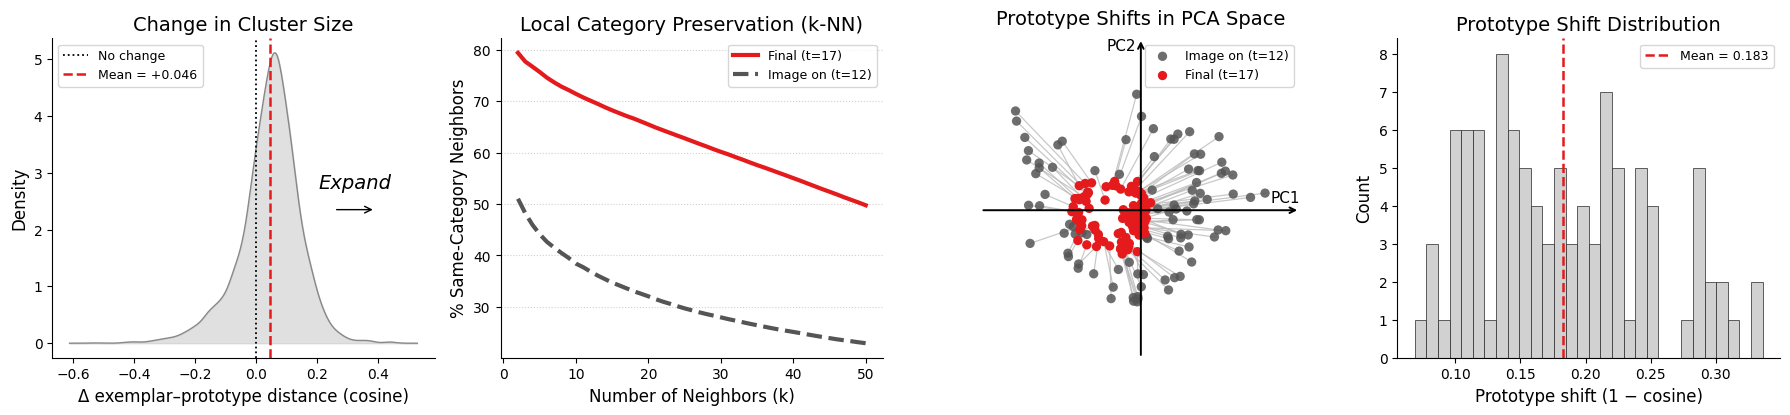

In [10]:
from repgeo import load_convrnn_states
from repgeo import pair_geometry_metrics

X, labels_c = load_convrnn_states(ACTIVATIONS, SUFFIX, states=("timgon", "tlast"), rep="logits")
print(pair_geometry_metrics(X["timgon"], X["tlast"], labels_c))

P.plot_convrnn_supplement(
    X["timgon"], X["tlast"], labels_c,
    before_label="Image on (t=12)", after_label="Final (t=17)")

## Untrained controls (separate supplement)

The random-weight, multi-seed controls live in their own runner because they
load a different activation set (`activations/untrained/`, 5 seeds per model):

```bash
python ../scripts/run_untrained_analysis.py \
    --activations ../activations/untrained \
    --out ../results/untrained --figures ../figures/untrained
```

Or interactively via `repgeo.untrained` — see that module's docstrings.